<a href="https://colab.research.google.com/github/adiburrahman2004/DeepSight/blob/main/DeepSight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CUDA Check**

In [1]:
import torch, cv2, pandas, sklearn, ultralytics, transformers, spacy, nltk
print("all good")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

all good
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti


# **DATA LOADING**

Loading the data directly from kaggle using **Kagglehub**

In [2]:
import os
import kagglehub
import pandas as pd


path = kagglehub.dataset_download("cl0ud0/news-political-bias-classification-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)

csv = []
for file in files:
    if 'csv' in file:
        csv.append(file)
print("Csv files in the dataset: ")
print(*csv)

Path to dataset files: C:\Users\onimr\.cache\kagglehub\datasets\cl0ud0\news-political-bias-classification-dataset\versions\1
Csv files in the dataset: 
news_bias.csv


In [3]:
csvdir = csv[0]
print(csvdir)

news_bias.csv


In [4]:
main_csv_file_path = path+'/'+csvdir

df = pd.read_csv(main_csv_file_path)


Showing first few rows/samples of the dataset

In [5]:
df.head(10)

,text,label
0,...,Right
1,Paul Manafort’s longtime associate...,Center
2,"Published22 November 2018Image source, JIM WAT...",Center
3,NEWYou can now listen to Fox News articles! A...,Right
4,"In mid-March, as San Francisco mayor London Br...",Center
5,Donald Trump has reiterated his threat to decl...,Left
6,NEWYou can now listen to Fox News articles! A...,Right
7,BEIJING (AP) — In the U.S. departure from Afgh...,Center
8,"KABUL, Afghanistan (AP) — Taliban militants at...",Center
9,WASHINGTON (Reuters) - The United States plans...,Center


# **SIMPLE EDA**

Structural Integrity, Data Types,
and Duplicate Checks

 1. Check exact dimensions
 2. Inspect column types and non-null counts
 3. Check for missing values in any column
 4. Check for duplicates (both full-row and text-only)


In [6]:
print("Shape:")
print(df.shape)
print("Info:")
print(df.info())
print("Missing Values:")
print(df.isnull().sum())
print("Duplicate samples:")
print(df['text'].duplicated().sum())
print(f"Exact duplicate rows (both feature and label): ")
print(df.duplicated().sum())
print(f"Duplicate features but different outputs:")
print(df['text'].duplicated().sum() - df.duplicated().sum())

Shape:
(17362, 2)
Info:
<class 'pandas.DataFrame'>
RangeIndex: 17362 entries, 0 to 17361
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    17362 non-null  str  
 1   label   17362 non-null  str  
dtypes: str(2)
memory usage: 104.0 MB
None
Missing Values:
text     0
label    0
dtype: int64
Duplicate samples:
303
Exact duplicate rows (both feature and label): 
291
Duplicate features but different outputs:
12


 # ****DATASET PREPROCESSING****

**Checking for Missing and Invalid Text**

Before applying text-processing operations, we check whether any articles are missing or contain invalid values.

Text-processing functions expect strings, so missing values should be identified before cleaning.

In [7]:
# Check for missing text values

print("Missing text values:")
print(df['text'].isna().sum())

# Check the data type of the text column

print("\nText column data type:")
print(df['text'].dtype)

Missing text values:
0

Text column data type:
str


In [8]:
# Check for empty articles

empty_text = df['text'].astype(str).str.strip().eq('').sum()

print("Empty articles:")
print(empty_text)

Empty articles:
0


Exact duplicates will leak data between train and test, and duplicate texts with different labels may work as noise and problems updating the parameters, we will remove both.


    1. Remove exact duplicate rows (matching both text and label)

    2. Count remaining texts that appear multiple times with conflicting labels

    3. Drop all conflicting text instances to prevent label noise




In [9]:
print("Original dataset size:")
print(len(df))
df = df.drop_duplicates(subset=['text', 'label'], keep='first') # keeping the first one and dropping next all duplicates
print("Size after dropping exact duplicates (keeping first one):")
print(len(df))
conflicting = df[df.duplicated(subset=['text'], keep=False)] # dropping all the cells that conflict as no solution can be drawn from this
print("Rows with duplicate text but conflicting labels:")
print(len(conflicting))
df = df.drop_duplicates(subset=['text'], keep=False).reset_index(drop=True)
print("Final dataset size after no duplicate:")
print(len(df))

Original dataset size:
17362
Size after dropping exact duplicates (keeping first one):
17071
Rows with duplicate text but conflicting labels:
24
Final dataset size after no duplicate:
17047


Statistical Analysis

    1.Compute character & word lengths
    2.Class distribution & imbalance ratio
    3.Word-count percentiles + summary statistics

In [10]:
df["char_count"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("Class Distribution: ")
class_counts = df["label"].value_counts()
class_percents = df["label"].value_counts(normalize=True) * 100
class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percents.round(2)
})
print(class_summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio (Majority / Minority): {imbalance_ratio:.2f}")

print("\nWord Count Percentiles: ")
percentiles = df["word_count"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).reset_index()
percentiles.columns = ["Quantile", "Word Count"]
print(percentiles)

print("\nWord Count Summary Statistics: ")
print(df["word_count"].describe().round(2))

Class Distribution: 
        Count  Percentage (%)
label                        
Left     7665           44.96
Right    5399           31.67
Center   3983           23.36

Imbalance Ratio (Majority / Minority): 1.92

Word Count Percentiles: 
   Quantile  Word Count
0      0.25      498.00
1      0.50      777.00
2      0.75     1126.00
3      0.90     1515.00
4      0.95     1827.40
5      0.99     3568.86

Word Count Summary Statistics: 
count     17047.00
mean        942.91
std        2298.96
min          49.00
25%         498.00
50%         777.00
75%        1126.00
max      204273.00
Name: word_count, dtype: float64


Data Inspection

    1.Extreme length outliers (> 5,000 words)
    2.Conflicting label duplicates

In [11]:
raw_outliers = df[df["word_count"] > 5000]

n = 0
print("Some Extremely big articles (outliers) (>5,000 words):")
for idx, row in raw_outliers.head().iterrows():
    n+=1
    print(f"No: {n} ")
    print(f"Label: {row['label']} | Word Count: {row['word_count']}")
    print(f"Text Snippet (First 400 chars):\n{row['text'][0:400]}...\n")
    print()

Some Extremely big articles (outliers) (>5,000 words):
No: 1 
Label: Center | Word Count: 8655
Text Snippet (First 400 chars):
   Summary
President Donald Trump and former Vice President Joe Biden faced off in the final presidential debate of the campaign. We found:
Trump accused Biden of receiving “$3.5 million from Russia.” There’s no evidence of that.
Biden said there’s “no evidence” that raising the minimum wage causes business bankruptcies. There is, a little.
Trump erred when he said it’s “proven” that a minimum-wag...


No: 2 
Label: Center | Word Count: 11276
Text Snippet (First 400 chars):
 Paul RyanRyan in 201854th Speaker of the United States House of RepresentativesIn officeOctober 29, 2015 – January 3, 2019Preceded byJohn BoehnerSucceeded byNancy PelosiLeader of the House Republican ConferenceIn officeOctober 29, 2015 – January 3, 2019Preceded byJohn BoehnerSucceeded byKevin McCarthyChair of the House Ways and Means CommitteeIn officeJanuary 3, 2015 – October 29, 2015Prece

Extreme Length Outlier Removal

    1.Count articles with > 5,000 words
    2.Remove all extreme outliers (word_count > 5,000)
    3.Report new dataset size after trimming
    4.Show updated word-count summary statistics

In [12]:
outliers = df[df["word_count"] > 5000]
print(f"Articles with more than 5,000 words: {len(outliers)}")

df = df[df["word_count"] <= 5000].reset_index(drop=True)

print(f"\nDataset size after removing outliers: {len(df)}")
print("\nUpdated Word Count Summary:")
print(df["word_count"].describe().round(2))

Articles with more than 5,000 words: 96

Dataset size after removing outliers: 16951

Updated Word Count Summary:
count    16951.00
mean       871.06
std        539.24
min         49.00
25%        497.00
50%        774.00
75%       1118.00
max       4953.00
Name: word_count, dtype: float64


**insight of the above works:**

When we looked at the raw data, we found a few articles that were ridiculously long — one even had over 200,000 words (basically the length of a full novel). Most articles are much shorter: 75% of them stay under about 1,200 words. Those extreme ones were almost certainly bad scrapes, full books, or accidentally merged pages, and they would have messed up our further works.

So we simply removed every article longer than 5,000 words. There were only 96 of them. After cleaning, the dataset dropped to 16,951 articles, and the longest one left is now 4953 words. The average article length settled around 870 words, which feels much more reasonable for almost all the models we are going to test in this project.

We also still have a moderate class imbalan We’ll need to use stratified splits so every set keeps the same proportions, and judge the model with Macro F1 instead of plain accuracy.


# **DATA NORMALIZATION AND TEXT PREPROCESSING**

**Text Normalization Strategy:**

As we are using text data for Classical ML (Logistic regression with TF-IDF) & Recurrent Networks (RNN/BiLSTM) and for Modern Transformers (RoBERTa/BERT), Wee need to be carefull when processing the txt. We keep capitalization, punctuation, and full sentence structure intact because transformer self-attention relies on grammar and context.
We apply lowercasing, punctuation stripping, and token-to-index vocabulary mapping for ML and Recurrent Deep Learning models.

**Text Processing — Inspecting Raw Articles**

Before cleaning the dataset, we first inspect several raw articles.

This helps us understand the structure of the text and identify common forms of noise, such as:
- URLs
- HTML tags
- author bylines
- publisher information
- datelines
- photo or image credits
- unnecessary whitespace


**Basic Technical Cleaning**

At first, We remove technical noise that does not contribute meaningful linguistic information. We will be using regex

The cleaning includes:
1. Removing HTML tags.
2. Removing URLs.
3. Removing unwanted control characters.
4. Normalizing repeated whitespace.



In [13]:
import re

def basic_clean(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'<[^>]+>', ' ', text)

    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    text = re.sub(r'[\x00-\x1F\x7F]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [14]:
df['cleaned_text'] = df['text'].apply(basic_clean)

**Structural Analysis of Articles**

Instead of removing names or organizations individually, we will examine the structure of the article.

Unwanted publisher data is more likely to be near the beginning or end of an article. So we first inspect the beginning and ending portions of articles.

In [15]:
for i in range(5):
    text = df['cleaned_text'].iloc[i]

    print(f"ARTICLE {i + 1}")

    print("\nBeginning:")
    print(text[:500])

    print("\nEnding:")
    print(text[-300:])

    print("\n" + "=" * 80)

ARTICLE 1

Beginning:
Twelve people were killed and four others were injured when a gunman opened fire at the Virginia Beach, Virginia, municipal center on Friday afternoon, officials said. Responding officers shot and killed the gunman, said Virginia Beach Police Chief James A. Cervera. One officer was injured and was expected to recover. “He was saved by his vest,” the chief told reporters. Chief Cervera described the suspect as a “longtime” and current employee of the city. He said the shooting was indiscriminate.

Ending:
d at the Princess Anne Middle School to reunite with loved ones who were in the building during the shooting. He said he saw his fiancee from across the parking lot, clearly in an agitated state. “I think she knew some of the people,” he said. • This article is based in part on wire service reports.

ARTICLE 2

Beginning:
Paul Manafort’s longtime associate, Richard Gates, testified Monday at the criminal trial of the former Trump campaign chairman that the two men

The inspection showed that some articles contain publisher-related or webpage boilerplate near the beginning or end, while others contain mostly clean article content. Therefore, we adopted a conservative structural cleaning approach rather than removing names or organizations indiscriminately.

We inspect the actual structure first, then make the smallest reasonable cleaning decision.

In [16]:
# Show the first part of the raw text with formatting characters visible

for i in range(5):
    print(f"\nARTICLE {i + 1}")
    print(repr(df['text'].iloc[i][:1000]))
    print("=" * 80)


ARTICLE 1
'                                                                                                                                         Twelve people were killed and four others were injured when a gunman opened fire at the Virginia Beach, Virginia, municipal center on Friday afternoon, officials said.                                                                                                                                                      Responding officers shot and killed the gunman, said Virginia Beach Police Chief James A. Cervera. One officer was injured and was expected to recover.                                                                                                                                                      “He was saved by his vest,” the chief told reporters.                                                                                                                                                                    Chief Cervera de

**General Text Cleaning and Boilerplate Removal**

After inspecting the dataset, we found that several articles contain web-page boilerplate and publisher-related information mixed with the article body.

Examples observed in the dataset include:

- Audio promotion such as "You can now listen to Fox News articles!"
- Author contact information such as "Write to [author] at [email]"
- Copyright notices and publisher rights information
- Image and photo credits
- Promotional sections such as "More From..." or "Click here to get the ... app"
- Other webpage-specific information

We will not completely remove every publisher name or organization from the articles as it might remove political figures like Trump or joe biden and may remove political party names thinking its a news organization.

Therefore, we remove only clearly identifiable boilerplate patterns while preserving the main article content.

The patterns we used here are selected after inspecting the dataset and identifying recurring boilerplate structures and also looking up to interet to find common boilerplate patterns.

We will be using regular expressions to filter these.

In [17]:
# Check how often some common boilerplate patterns appear

patterns = [
    r'copyright',
    r'write to .*@',
    r'you can now listen',
    r'click here to get .* app',
    r'image source',
    r'image caption',
    r'more from',
    r'more on this story'
]

for pattern in patterns:
    count = df['cleaned_text'].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    ).sum()

    print(pattern, "->", count)

copyright -> 997
write to .*@ -> 680
you can now listen -> 1598
click here to get .* app -> 404
image source -> 232
image caption -> 216
more from -> 405
more on this story -> 215


By applying common boilerplates from the internet we find that the dataset contains the audio-promotion phrase "You can now listen to..." in many articles and repeatedly has author informations and copyright claims.

For example:

    "Write to Aruna Viswanatha at Aruna.Viswanatha@wsj.com"

    "Write to John Smith at john.smith@example.com"

have different names and email addresses, but share the same structural pattern.

Similarly, copyright notices may have different years and company names, so the cleaning rule focuses on the common structure rather than a specific company.

Although it removes many of the boilerplates but it has its own limitations and we can not manually check all 17047 articles to find all the boilerplates.

So we create a function to remove the common news boilerplate pattern texts using regular expression.

In [18]:
def remove_common_boilerplate(text):

    # Remove audio promotion
    text = re.sub(
        r'NEW\s*You can now listen to [^.!?]+[.!?]?',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # Remove author email/contact information
    text = re.sub(
        r'Write to [^.]*at [\w.-]+@[\w.-]+\.\w+',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # Remove copyright footer and everything following it
    text = re.sub(
        r'Copyright\s*©?.*$',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove image/photo credit information
    text = re.sub(
        r'\(?\s*(?:Photo|Image)\s+(?:by|source|credit)\b[^).]*\)?',
        ' ',
        text,
        flags=re.IGNORECASE
    )


    return text.strip()



In [19]:
df['cleaned_text'] = df['cleaned_text'].apply(remove_common_boilerplate)

At this point we are willing to remove newspaper names as the model might get biased itself towards newspaper names. Therefore we will follow this [web article ](https://pressgazette.co.uk/media-audience-and-business-data/media_metrics/most-popular-websites-news-world-monthly-2/ ) to remove names of the top 50 News hub in the world

In [20]:
# Compare Articles 2 and 4 before and after cleaning

for i in [2, 3]:
    print(f"ARTICLE {i + 1}")

    print("\nBEFORE:")
    print(df['text'].iloc[i][-700:])

    print("\nAFTER:")
    print(df['cleaned_text'].iloc[i][-700:])

    print("\n" + "=" * 80)

ARTICLE 3

BEFORE:
n coming weeks.On Tuesday, the Pentagon released a report to Congress saying the deployment of around 5,900 active-duty troops would cost about $72m (£56m), plus the $138m (£108m) already spent on 2,100 National Guard troops on border missions since April.In addition, more than $80m (£62m) has been spent to process thousands of migrant children separated from parents under the Trump administration's "zero tolerance" crackdown earlier this year, report US media. Mr Trump eventually backed down on the policy that saw over 2,000 migrant children taken away from adults at the US-Mexico border between May and June.Around 140 children remain in government custody as of this week.More on this story

AFTER:
n coming weeks.On Tuesday, the Pentagon released a report to Congress saying the deployment of around 5,900 active-duty troops would cost about $72m (£56m), plus the $138m (£108m) already spent on 2,100 National Guard troops on border missions since April.In addition, mor

# **Train-Test Split**

In EDA part we saw heavy class imbalance in dataset. Since the target classes show moderate imbalance, we use a stratified train-test split,so the label distribution remains consistant.

The split is performed before fitting text-based feature extraction methods such as TF-IDF to prevent information leakage from the test set into the training process.

In [21]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13560
Testing samples: 3391


**Verifying the Train-Test Split**

Before applying text vectorization, we verify that stratification preserved the original class distribution in both the training and testing sets.

In [22]:
print("Training label distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training label distribution:
label
Left      44.778761
Right     31.792035
Center    23.429204
Name: proportion, dtype: float64

Testing label distribution:
label
Left      44.765556
Right     31.790032
Center    23.444412
Name: proportion, dtype: float64


looks perfect

# TF-IDF Feature Extraction


To make sure ML models can read trough the texts we need to convert them to numerical values.

We use Term Frequency-Inverse Document Frequency (TF-IDF) to represent each sample datapoint (in this case the articles) based on the importance of the words it contains.

TF-IDF gives higher importance to words that are more common in a particular datapoint but less common across the entire training dataset.

The TF-IDF vectorizer converts the datapoints into vector and will be fitted only on the training data to prevent data leakage.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer( # creates a sparse matrix with features where feature can be ngram where n = (1,2)
    ngram_range=(1, 2), # both unigram and bigram sequences
    min_df= 3 , # ignore a feature if it appears in less than 3 datapoints(articles)
    max_df=0.9 # ignore a feature that appears in more than 90% of the datapoints
)

X_train_tfidf = tfidf.fit_transform(X_train) # fit ensures the model learns from training
X_test_tfidf = tfidf.transform(X_test) # transform ensures all the training data turns into specific TF-IDF vector

print("Training TF-IDF shape:", X_train_tfidf.shape)
#print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (13560, 293993)


from the TF IDF vectorizer we found about 300k features.
300k features means:

    -much larger feature space
    -slower Logistic Regression
    -more memory
    -many rare/noisy bigrams
    -risk of overfitting






Although the feature number is Huge , we will still keep the 294k features to train the logistic regression model.

# Logistic Regression

Logistic Regression is used as the first baseline classifier for political bias detection.

The model receives the TF-IDF representation of each article and figures out a relationship between the extracted textual features and the three political bias classes: Left, Center, and Right.

we will later compare it with the RNN, BiLSTM, and RoBERTa models.

In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


**Baseline Model Evaluation**

After training the Logistic Regression classifier, we evaluate its performance on the unseen testing set.

We use accuracy, precision, recall, and specially **F1-score** to measure overall and class-specific performance. F1 score is better for unbalanced dataset.



In [25]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_reg.predict(X_test_tfidf)

print("Logistic Regression Training Evaluation:")
print("-"*50)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Training Evaluation:
--------------------------------------------------
Accuracy: 0.7463874963137718

Classification Report:
              precision    recall  f1-score   support

      Center       0.90      0.60      0.72       795
        Left       0.70      0.89      0.78      1518
       Right       0.76      0.65      0.70      1078

    accuracy                           0.75      3391
   macro avg       0.79      0.71      0.74      3391
weighted avg       0.77      0.75      0.74      3391



**Confusion Matrix**


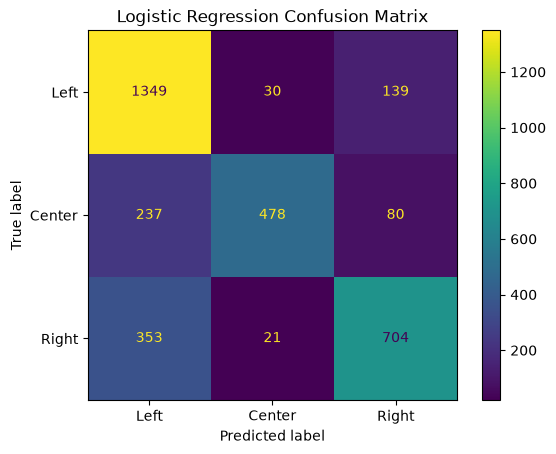

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Left", "Center", "Right"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left", "Center", "Right"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [4]:
import subprocess

commands = [
    "echo \"# DeepSight\" >> README.md",
    "git init",
    "git add README.md DeepSight.ipynb", # Modified line to specifically add README.md and the notebook
    "git commit -m \"first commit\"",
    "git branch -M main",
    "git remote add origin https://github.com/adiburrahman2004/DeepSight.git",
    "git push -u origin main"
]

for cmd in commands:
    try:
        print(f"Executing: {cmd}")
        result = subprocess.run(cmd, shell=True, check=True, capture_output=True, text=True)
        print(result.stdout)
        if result.stderr:
            print(result.stderr)
    except subprocess.CalledProcessError as e:
        print(f"Error executing command: {cmd}")
        print(e.stdout)
        print(e.stderr)
        break


Executing: echo "# DeepSight" >> README.md

Executing: git init
Reinitialized existing Git repository in C:/Users/onimr/.git/

Executing: git add README.md DeepSight.ipynb
Error executing command: git add README.md DeepSight.ipynb

fatal: pathspec 'DeepSight.ipynb' did not match any files



In [5]:
!dir

 Volume in drive C is WIN-10
 Volume Serial Number is 5E8C-06FA

 Directory of C:\Users\onimr

18/08/2026  11:08    <DIR>          .
30/01/2026  23:12    <DIR>          ..
10/02/2026  16:09               800 .bash_history
17/08/2026  17:41    <DIR>          .cache
11/07/2026  23:11    <DIR>          .cagent
22/06/2026  12:52    <DIR>          .claude
19/07/2026  22:20               778 .claude.json
19/05/2026  23:35    <DIR>          .cline
16/04/2026  00:58    <DIR>          .codex
13/02/2025  18:29                43 .condarc
25/05/2026  14:24    <DIR>          .config
19/07/2026  22:28    <DIR>          .continue
19/07/2026  22:34    <DIR>          .copilot
31/05/2026  15:21    <DIR>          .cursor
23/07/2026  01:49    <DIR>          .docker
28/01/2026  00:12               718 .drjava
22/04/2026  20:04    <DIR>          .ghcp-appmod
22/04/2026  20:04    <DIR>          .ghcp-appmod-java
05/08/2026  18:19               288 .gitconfig
06/07/2026  22:37    <DIR>          .ipynb_checkpo